In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
import gc # Garbage Collector
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Capstone/Capstone Draft/merge.csv')
display(df.head())

/tmp/ipykernel_8170/1242828677.py:1: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Capstone/Capstone Draft/merge.csv')


,network_code,receiver_code,receiver_type,receiver_latitude,receiver_longitude,receiver_elevation_m,p_arrival_sample,p_status,p_weight,p_travel_sec,...,source_magnitude_author,source_mechanism_strike_dip_rake,source_distance_deg,source_distance_km,back_azimuth_deg,snr_db,coda_end_sample,trace_start_time,trace_category,trace_name
0,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-10-21 05:55:00,noise,109C.TA_201510210555_NO
1,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-06 14:50:00,noise,109C.TA_201511061450_NO
2,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-07 02:20:00,noise,109C.TA_201511070220_NO
3,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-14 05:15:00,noise,109C.TA_201511140515_NO
4,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-12-25 18:50:00,noise,109C.TA_201512251850_NO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1265657 entries, 0 to 1265656
Data columns (total 35 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   network_code                      1265613 non-null  object 
 1   receiver_code                     1265657 non-null  object 
 2   receiver_type                     1265657 non-null  object 
 3   receiver_latitude                 1265657 non-null  float64
 4   receiver_longitude                1265657 non-null  float64
 5   receiver_elevation_m              1265657 non-null  float64
 6   p_arrival_sample                  1030231 non-null  float64
 7   p_status                          1030231 non-null  object 
 8   p_weight                          1030057 non-null  float64
 9   p_travel_sec                      1030231 non-null  float64
 10  s_arrival_sample                  1030231 non-null  float64
 11  s_status                          103

# **Our Target Variable -> trace_category**
🚨Picks 5000 random sample and keeps the state same using random_state=42

In [ ]:
eq_df = df[df['trace_category'] == 'earthquake_local'].sample(5000, random_state=42)
noise_df = df[df['trace_category'] == 'noise'].sample(5000, random_state=42)

In [ ]:
eq_df

,network_code,receiver_code,receiver_type,receiver_latitude,receiver_longitude,receiver_elevation_m,p_arrival_sample,p_status,p_weight,p_travel_sec,...,source_magnitude_author,source_mechanism_strike_dip_rake,source_distance_deg,source_distance_km,back_azimuth_deg,snr_db,coda_end_sample,trace_start_time,trace_category,trace_name
270060,AK,ATKA,BH,52.201600,-174.197500,55.0,898.2,autopicker,0.83,10.20600,...,NaN,NaN,0.48200,53.71,216.12,[24.89999962 31. 26.39999962],[[2485.]],2018-06-29 22:15:45.108000,earthquake_local,ATKA.AK_20180629221544_EV
920184,NN,LHV,HH,38.251300,-118.504900,2353.0,900.0,manual,0.95,4.12653,...,NaN,NaN,0.18300,20.41,269.92,[12.39999962 13.69999981 11.60000038],[[2248.]],2016-08-06 09:11:39.403530,earthquake_local,LHV.NN_20160806091138_EV
431384,PB,B087,EH,33.495500,-116.602667,1139.0,800.0,manual,0.61,4.18000,...,CI,NaN,0.20030,22.28,126.00,[38.79999924 37.90000153 35.29999924],[[1695.]],2010-10-13 01:23:15.680000,earthquake_local,B087.PB_20101013012314_EV
414081,PB,B086,EH,33.557500,-116.531000,1392.0,800.0,manual,0.59,10.71000,...,CI,NaN,0.57080,63.47,318.00,[19.89999962 18.89999962 16.60000038],[[2144.]],2008-02-01 17:46:34.400000,earthquake_local,B086.PB_20080201174633_EV
622739,CI,CJV2,HH,34.529780,-118.144500,1296.0,800.0,manual,0.61,7.68000,...,NaN,NaN,0.41310,45.93,267.10,[9.19999981 6.80000019 4. ],[[3199.]],2017-08-29 04:10:21.710000,earthquake_local,CJV2.CI_20170829041020_EV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302688,PB,B076,EH,35.939800,-120.424800,445.0,700.0,manual,0.61,3.42000,...,NaN,NaN,0.12970,14.46,300.10,[44.40000153 39. 42.90000153],[[1519.]],2014-07-10 07:02:54.520000,earthquake_local,B076.PB_20140710070253_EV
1087057,AK,RC01,BH,61.088900,-149.739000,390.0,600.0,manual,0.95,10.68700,...,NaN,NaN,0.57100,63.72,252.28,[33.20000076 29. 30.79999924],[[2348.]],2017-09-14 17:43:30.014000,earthquake_local,RC01.AK_20170914174329_EV
580635,SN,BTW,EH,36.997800,-116.567400,1391.0,800.0,manual,0.95,3.68400,...,NN,NaN,0.19100,21.20,205.27,[34.09999847 38.40000153 36.09999847],[[2083.]],2012-10-11 09:25:43.200000,earthquake_local,BTW.SN_20121011092542_EV
750702,NC,GDXB,HH,38.807968,-122.795303,939.0,700.0,autopicker,0.93,0.70000,...,NC,NaN,0.01261,1.43,2.00,[31.10000038 28.20000076 29.89999962],[[1672.]],2012-06-19 01:51:07.110000,earthquake_local,GDXB.NC_20120619015106_EV


In [ ]:
noise_df

,network_code,receiver_code,receiver_type,receiver_latitude,receiver_longitude,receiver_elevation_m,p_arrival_sample,p_status,p_weight,p_travel_sec,...,source_magnitude_author,source_mechanism_strike_dip_rake,source_distance_deg,source_distance_km,back_azimuth_deg,snr_db,coda_end_sample,trace_start_time,trace_category,trace_name
8306,GM,AA12,HH,39.535230,-121.466900,385.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-03-21 05:10:00,noise,AA12.GM_201803210510_NO
85069,UO,DBO,HH,43.119170,-123.242830,984.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-22 17:50:00,noise,DBO.UO_201807221750_NO
111403,DK,ISOG,HH,65.547997,-38.975700,12.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-15 03:11:06,noise,ISOG.DK_20180115031106_NO
174881,TX,PB12,HH,31.213240,-103.957703,961.6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-17 18:00:48,noise,PB12.TX_20200317180048_NO
77342,LD,CPNY,HH,40.791100,-73.960197,27.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-16 02:17:54,noise,CPNY.LD_20180116021754_NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120088,NC,JPC,HN,37.270800,-122.212760,257.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-06-26 10:49:00,noise,JPC.NC_200706261049_NO
169666,TX,PB06,HH,31.647200,-103.218246,831.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-15 07:44:06,noise,PB06.TX_20200315074406_NO
175240,TX,PB12,HH,31.213240,-103.957703,961.6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-19 05:10:06,noise,PB12.TX_20200319051006_NO
193565,NC,PSAB,HN,36.024860,-120.889270,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-06 13:54:00,noise,PSAB.NC_201801061354_NO


In [ ]:
print("Missing values in earthquake_df:")
display(eq_df.isnull().sum())

print("\nMissing values in noise_df:")
display(noise_df.isnull().sum())

Missing values in earthquake_df:


,0
network_code,1
receiver_code,0
receiver_type,0
receiver_latitude,0
receiver_longitude,0
receiver_elevation_m,0
p_arrival_sample,0
p_status,0
p_weight,0
p_travel_sec,0



Missing values in noise_df:


,0
network_code,0
receiver_code,0
receiver_type,0
receiver_latitude,0
receiver_longitude,0
receiver_elevation_m,0
p_arrival_sample,5000
p_status,5000
p_weight,5000
p_travel_sec,5000


In [ ]:
# শুধু ভূমিকম্পের রোগুলো
eq_clean = df[df['trace_category'] == 'earthquake_local'].dropna(subset=['source_magnitude', 'p_arrival_sample'])

# শুধু নয়েজ রোগুলো
noise_clean = df[df['trace_category'] == 'noise'].sample(n=len(eq_clean), replace=True, random_state=42)

# ফাইনাল মেটাডেটা
df_final = pd.concat([eq_clean, noise_clean])

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2060462 entries, 235426 to 187644
Data columns (total 35 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   network_code                      object 
 1   receiver_code                     object 
 2   receiver_type                     object 
 3   receiver_latitude                 float64
 4   receiver_longitude                float64
 5   receiver_elevation_m              float64
 6   p_arrival_sample                  float64
 7   p_status                          object 
 8   p_weight                          float64
 9   p_travel_sec                      float64
 10  s_arrival_sample                  float64
 11  s_status                          object 
 12  s_weight                          float64
 13  source_id                         object 
 14  source_origin_time                object 
 15  source_origin_uncertainty_sec     float64
 16  source_latitude                   flo

In [ ]:
def generate_synthetic_wave(row, duration=2, sampling_rate=100):
    """
    STEAD মেটাডেটা ব্যবহার করে সিসমিক ওয়েভ তৈরি করার ফাংশন
    """
    t = np.linspace(0, duration, duration * sampling_rate) # ২ সেকেন্ডের টাইমলাইন
    mag = row['source_magnitude']

    # ১. P-wave (Primary wave): দ্রুত এবং ছোট কম্পন
    p_freq = np.random.uniform(8, 15)
    p_wave = (mag * 0.15) * np.sin(2 * np.pi * p_freq * t) * np.exp(-t * 2.5)

    # ২. S-wave (Secondary wave): ধীর কিন্তু শক্তিশালী ধ্বংসাত্মক কম্পন
    # P এবং S ওয়েভের মাঝখানে সামান্য গ্যাপ থাকে (S-delay)
    s_freq = np.random.uniform(2, 5)
    s_delay = 0.4
    s_wave = np.zeros_like(t)
    s_mask = t > s_delay
    s_wave[s_mask] = mag * np.sin(2 * np.pi * s_freq * (t[s_mask] - s_delay)) * np.exp(-(t[s_mask] - s_delay))

    # ৩. Background Noise: শহরের সাধারণ কম্পন যোগ করা
    noise = np.random.normal(0, 0.05, len(t))

    # ৪. কম্বাইন্ড সিগন্যাল
    combined = p_wave + s_wave + noise

    # ৫. Normalization: ডাটাকে -১ থেকে ১ এর মধ্যে আনা (LSTM এর জন্য জরুরি)
    combined = combined / (np.max(np.abs(combined)) + 1e-9)

    return combined

In [ ]:
# ১. আগে থেকেই খালি একটি Numpy Array তৈরি করে রাখা (লিস্টের চেয়ে অনেক সাশ্রয়ী)
num_samples = len(df_final)
X_final = np.zeros((num_samples, 200), dtype=np.float32) # float32 মেমরি কম নেয়
y_final = np.zeros(num_samples, dtype=np.int8)

# ২. লুপের মাধ্যমে ডাটা ভরা
print("Starting data generation...")
for i, (idx, row) in enumerate(df_final.iterrows()):
    if row['trace_category'] == 'earthquake_local':
        X_final[i] = generate_synthetic_wave(row).astype(np.float32)
        y_final[i] = 1
    else:
        # সরাসরি numpy array তে এসাইন করা
        X_final[i] = np.random.normal(0, 0.05, 200).astype(np.float32)
        y_final[i] = 0

    # প্রতি ১০০০ স্যাম্পল পর পর স্ট্যাটাস দেখা
    if i % 1000 == 0:
        print(f"Processed {i}/{num_samples} samples")

# ৩. মেমরি খালি করা (অপ্রয়োজনীয় মেটাডেটা ডিলিট করা)
# df_final আর প্রয়োজন নেই যদি ডাটা জেনারেট হয়ে যায়
del df_final
gc.collect()

# ৪. রিশেপ করা (LSTM এর জন্য)
X_final = X_final.reshape(X_final.shape[0], X_final.shape[1], 1)

# ৫. স্প্লিট করা
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# স্প্লিট করার পর X_final ডিলিট করে RAM বাঁচানো
del X_final
gc.collect()

print("Data ready! RAM issues should be resolved.")

Starting data generation...
Processed 0/2060462 samples
Processed 1000/2060462 samples
Processed 2000/2060462 samples
Processed 3000/2060462 samples
Processed 4000/2060462 samples
Processed 5000/2060462 samples
Processed 6000/2060462 samples
Processed 7000/2060462 samples
Processed 8000/2060462 samples
Processed 9000/2060462 samples
Processed 10000/2060462 samples
Processed 11000/2060462 samples
Processed 12000/2060462 samples
Processed 13000/2060462 samples
Processed 14000/2060462 samples
Processed 15000/2060462 samples
Processed 16000/2060462 samples
Processed 17000/2060462 samples
Processed 18000/2060462 samples
Processed 19000/2060462 samples
Processed 20000/2060462 samples
Processed 21000/2060462 samples
Processed 22000/2060462 samples
Processed 23000/2060462 samples
Processed 24000/2060462 samples
Processed 25000/2060462 samples
Processed 26000/2060462 samples
Processed 27000/2060462 samples
Processed 28000/2060462 samples
Processed 29000/2060462 samples
Processed 30000/2060462 s

In [ ]:
# ১. মডেল আর্কিটেকচার ডিফাইন করা
model = Sequential([
    # প্রথম LSTM লেয়ার (১৬টি ইউনিট যথেষ্ট কারণ ESP32-এর মেমরি কম)
    LSTM(16, input_shape=(200, 1), return_sequences=False),

    # ওভারফিটিং কমানোর জন্য ড্রপআউট
    Dropout(0.2),

    # ব্যাচ নরমালাইজেশন (ট্রেনিং দ্রুত করার জন্য)
    BatchNormalization(),

    # একটি ছোট ডেন্স লেয়ার
    Dense(8, activation='relu'),

    # আউটপুট লেয়ার (বাইনারি ক্লাসিফিকেশন: ০ বা ১)
    Dense(1, activation='sigmoid')
])

# ২. মডেল কমপাইল করা
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Defined Successfully!")
model.summary()

✅ Model Defined Successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,329 (5.19 KB)

 Non-trainable params: 32 (128.00 B)

In [ ]:
# ১. ১ লক্ষ স্যাম্পল আলাদা করা (যদি আগে না করে থাকেন)
sample_size = 100000
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_train_small = X_train[indices]
y_train_small = y_train[indices]

# ২. ট্রেনিং শুরু (সবচেয়ে উত্তেজনাপূর্ণ ধাপ!)
print("🚀 Training Started... This may take a few minutes.")
history = model.fit(
    X_train_small,
    y_train_small,
    epochs=5,            # 5 বার পুরো ডাটা ঘুরে দেখবে
    batch_size=64,        # একবারে ৬৪টি করে স্যাম্পল প্রসেস করবে
    validation_data=(X_test, y_test), # টেস্ট ডাটা দিয়ে নিজেকে যাচাই করবে
    verbose=1             # ট্রেনিংয়ের অগ্রগতি দেখাবে
)

🚀 Training Started... This may take a few minutes.
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 86ms/step - accuracy: 0.9382 - loss: 0.1333 - val_accuracy: 0.9914 - val_loss: 0.0445
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.9859 - loss: 0.0686 - val_accuracy: 0.9820 - val_loss: 0.0813
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - accuracy: 0.9614 - loss: 0.1089 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 84ms/step - accuracy: 0.9997 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 7.0474e-05
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 90ms/step - accuracy: 0.9999 - loss: 5.0937e-04 - val_accuracy: 1.0000 - val_loss: 1.6644e-05


12878/12878 ━━━━━━━━━━━━━━━━━━━━ 122s 9ms/step


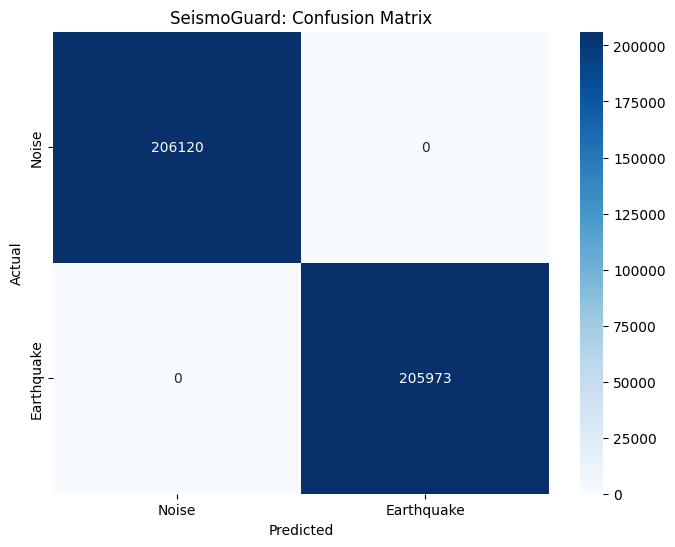


Detailed Classification Report:
              precision    recall  f1-score   support

       Noise       1.00      1.00      1.00    206120
  Earthquake       1.00      1.00      1.00    205973

    accuracy                           1.00    412093
   macro avg       1.00      1.00      1.00    412093
weighted avg       1.00      1.00      1.00    412093



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict labels for the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Noise', 'Earthquake'],
            yticklabels=['Noise', 'Earthquake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SeismoGuard: Confusion Matrix')
plt.show()

# 4. Print detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Noise', 'Earthquake']))